## TEXT CLASSIFICATION AND SENTIMENT ANALYSIS

#### Improving Customer Satisfaction through Automated Review Sentiment Analysis

#### Overview

You are a product manager at an e-commerce company like Amazon. Your company receives thousands of customer reviews daily for various products. While ratings are available, they don’t always capture customer sentiment accurately — especially when the text and rating conflict.
    
#### Business Problem:
    
Your goal is to build an automated Sentiment Analysis System to classify incoming product reviews as Positive or Negative. This will help:
    
•	Monitor product performance in real-time

•	Identify products with sudden spikes in negative feedback

•	Improve customer satisfaction by addressing complaints faster


#### Dataset

•	Each row is one Amazon customer review for some product.
    
•	The dataset has been pre-labeled — so you already know if the review is positive or negative.
    
•	This is a typical sentiment analysis dataset, often used for training or testing natural language processing (NLP) models.


##### Rows:

10,000 customer reviews


#### Columns:
    
##### 1.	label
    
o	Type: Text (Categorical)

o	Values: pos (positive) or neg (negative)

o	What it means: The sentiment of the review — whether the customer’s feedback is positive or negative.


##### 2.	review

o	Type: Text

o	Values: Actual text of the review written by the customer.
    
o	What it means: What the customer said about the product in their own words — for example: “Excellent Soundtrack! I love it!”


##### Tasks

##### Data Cleaning:

    Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rakshitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords

# Load dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\amazonreviews.tsv", sep='\t')

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna(subset=['review'])

# Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_review'] = df['review'].apply(preprocess_text)

print(df[['review', 'cleaned_review']].head())

                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                      cleaned_review  
0  stuning even nongamer sound track beautiful pa...  
1  best soundtrack ever anything im reading lot r...  
2  amazing soundtrack favorite music time hands i...  
3  excellent soundtrack truly like soundtrack enj...  
4  remember pull jaw floor hearing youve played g...  


##### Exploratory Analysis: 

Word clouds, sentiment distribution, most common positive/negative words.

In [6]:
pip install wordcloud matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rakshitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Index(['label', 'review', 'cleaned_review'], dtype='object')


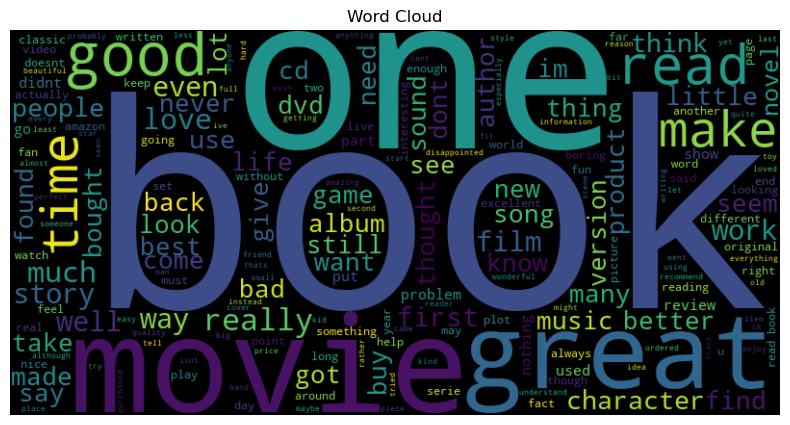

Index(['label', 'review', 'cleaned_review', 'cleaned_words'], dtype='object')


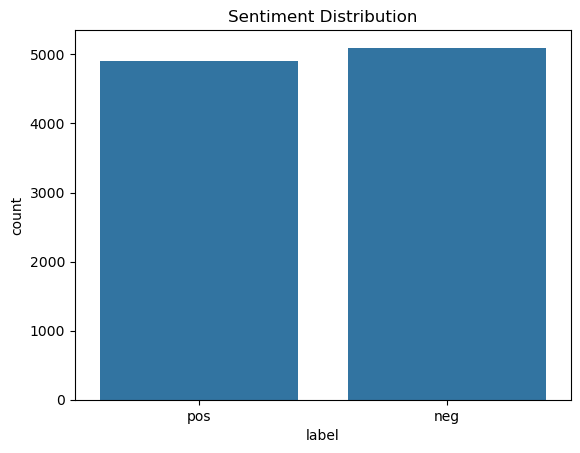

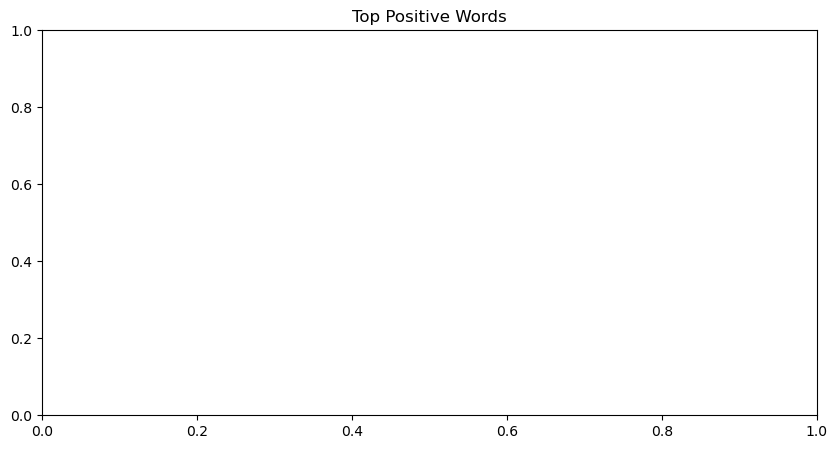

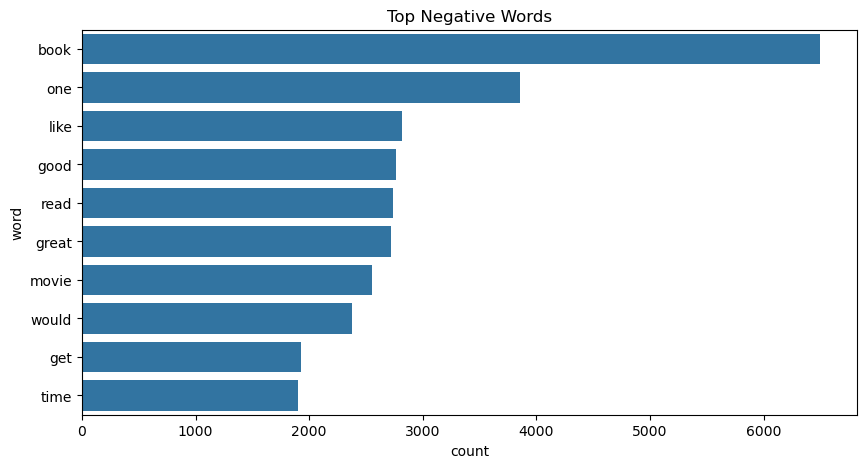

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
import re

from nltk.corpus import stopwords
nltk.download('stopwords')

# Keep relevant columns (adjust if needed)
# Assume columns: 'review' and 'label' (or 'sentiment')
print(df.columns)

# Drop missing values and duplicates
df = df.drop_duplicates()
df = df.dropna(subset=['review'])

# Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

df['cleaned_words'] = df['review'].apply(clean_text)

# -----------------------------
# 1. WORD CLOUD
# -----------------------------
all_words = " ".join([" ".join(words) for words in df['cleaned_words']])

wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

# -----------------------------
# 2. SENTIMENT DISTRIBUTION
# -----------------------------
# Adjust column name if different (e.g., 'label' or 'sentiment')
print(df.columns)

sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

# -----------------------------
# 3. MOST COMMON WORDS BY SENTIMENT
# -----------------------------

# Separate positive and negative reviews
positive_words = []
negative_words = []

for _, row in df.iterrows():
    if row['label'] == 1 or row['label'] == 'positive':
        positive_words.extend(row['cleaned_words'])
    else:
        negative_words.extend(row['cleaned_words'])

# Most common words
pos_common = Counter(positive_words).most_common(10)
neg_common = Counter(negative_words).most_common(10)

# Convert to DataFrame for plotting
pos_df = pd.DataFrame(pos_common, columns=['word', 'count'])
neg_df = pd.DataFrame(neg_common, columns=['word', 'count'])

# Plot Positive Words
plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=pos_df)
plt.title("Top Positive Words")
plt.show()

# Plot Negative Words
plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=neg_df)
plt.title("Top Negative Words")
plt.show()

##### Model Development: 

Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\amazonreviews.tsv", sep='\t')

# Drop missing and duplicates
df = df.drop_duplicates(subset=['review'])
df = df.dropna(subset=['review'])

# Features and target
X = df['review']
y = df['label']   # change if your column name is different

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# SVM Model
svm = SVC(kernel='linear')
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.8655
              precision    recall  f1-score   support

         neg       0.87      0.88      0.87      1037
         pos       0.87      0.85      0.86       963

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

